In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

notebook_dir = os.getcwd() 
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))  # ../src
sys.path.append(src_path)

from plot import plot_cancellation_guests

sns.set(style="whitegrid") 
df_clean = pd.read_parquet('../data/hotels_clean.parquet' , engine='fastparquet') 
print(f"Cleaned dataset shape: {df_clean.shape}")
display(df_clean.head(3))

Cleaned dataset shape: (78528, 19)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,total_guests,total_nights
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,0,0,0,A,C,1,1
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,0,0,0,A,A,1,1
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,0,0,0,A,A,2,2


Figure saved to ../figures/guests_all.png


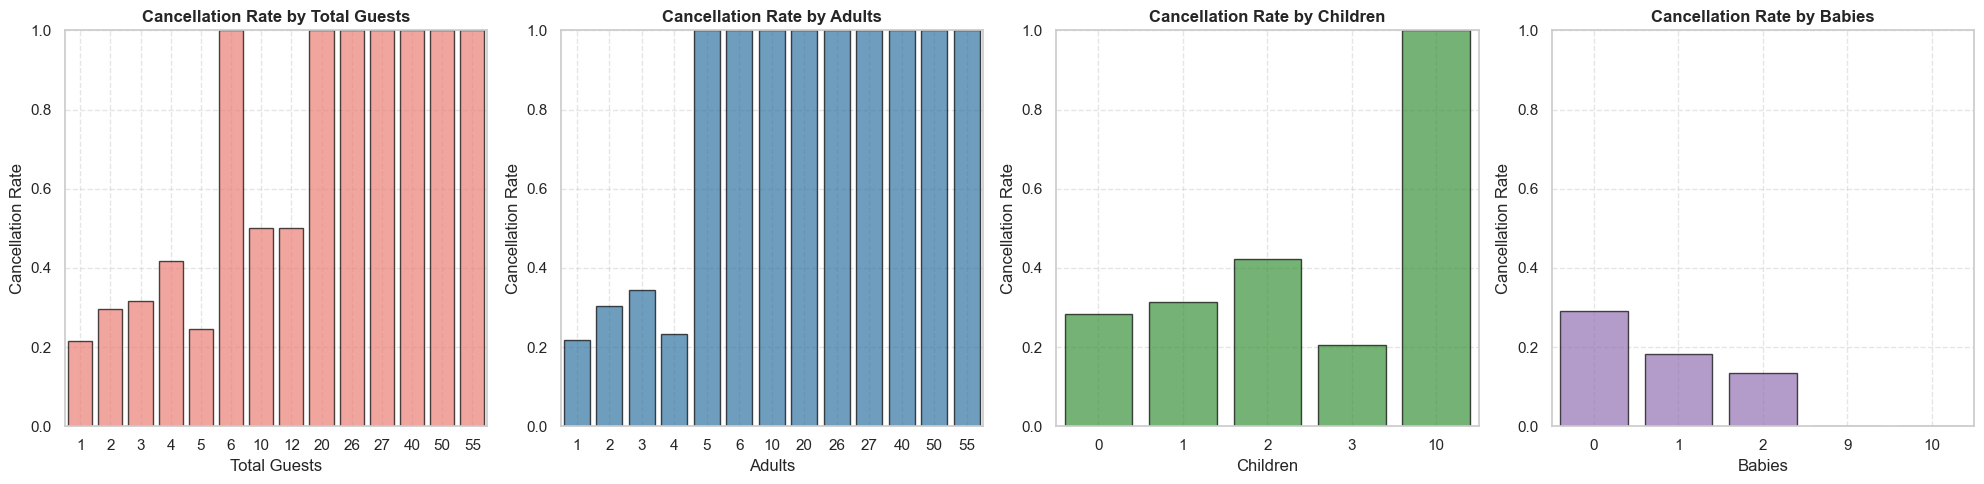

In [2]:
data_plot = df_clean.copy()
plot_cancellation_guests(data_plot, save_path="../figures/guests_all.png")

In [3]:
# --- Filter dataset to exclude unusual bookings ---
# Keep only bookings with:
# 1 adults ≤ 4 (to avoid groups with extremely high cancellation rates)
# This helps ensure regression and cancellation analysis focuses on representative data

rows_original = df_clean.shape[0]

df_filtered_adults = df_clean[df_clean['adults'] <= 4].copy()
rows_after_adults = df_filtered_adults.shape[0]
removed_adults = rows_original - rows_after_adults
percent_removed_adults = removed_adults / rows_original * 100

print(f"Removed {removed_adults} rows with adults > 4 ({percent_removed_adults:.2f}%)")

Removed 16 rows with adults > 4 (0.02%)


Figure saved to ../figures/guests_adults_filter.png


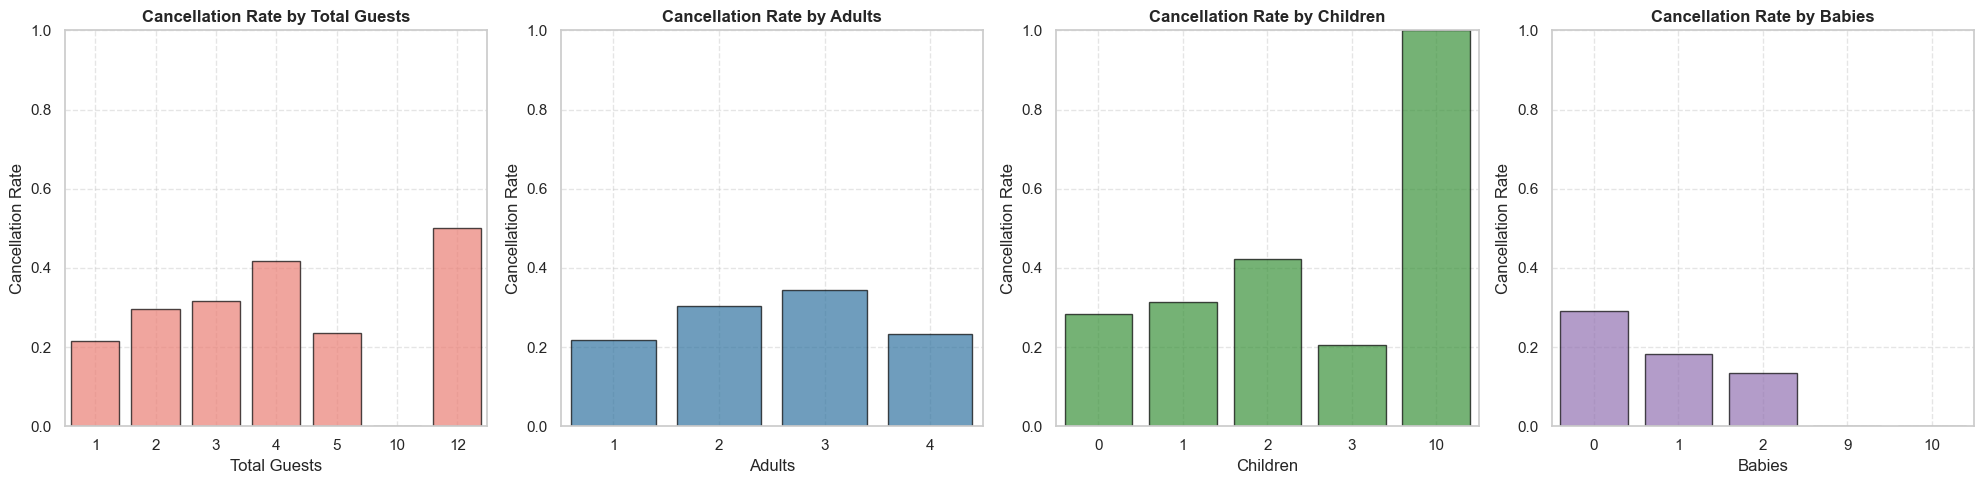

In [4]:
data_plot = df_filtered_adults.copy()
plot_cancellation_guests(data_plot, save_path="../figures/guests_adults_filter.png")

In [5]:
# --- Filter dataset to exclude unusual bookings ---
# Observed distribution of total_guests shows a sharp jump:
#   - Most bookings: total_guests ≤ 5
#   - Very few bookings at total_guests = 12 (likely an anomaly)
# Check the largest non-canceled booking:
non_canceled = data_plot[data_plot['is_canceled'] == 0]
max_guests_row = non_canceled.loc[non_canceled['total_guests'].idxmax()]

print("=== Largest Non-Canceled Booking Details ===")
print(f"Total Guests: {max_guests_row['total_guests']}")
print(f"Breakdown: Adults {max_guests_row['adults']}, Children {max_guests_row['children']}, Babies {max_guests_row['babies']}")
print(f"Arrival Date: {max_guests_row['arrival_date_year']} - {max_guests_row['arrival_date_month']}")
print(f"Assigned Room Type: {max_guests_row['assigned_room_type']}")
print("============================================\n")

=== Largest Non-Canceled Booking Details ===
Total Guests: 12
Breakdown: Adults 2, Children 0, Babies 10
Arrival Date: 2016 - January
Assigned Room Type: D



In [6]:
# --- Filter dataset to exclude unusual bookings ---
# Keep only bookings with:
# 1 adults ≤ 4 (to avoid groups with extremely high cancellation rates)
# 2 children ≤ 3 (to exclude anomalous entries like children = 10 which likely represent data errors)
# This helps ensure regression and cancellation analysis focuses on representative data

rows_original = df_clean.shape[0]

df_filtered = df_clean[(df_clean['adults'] <= 4) & (df_clean['children'] <= 3)].copy()

rows_after_adults = df_filtered.shape[0]
removed_adults = rows_original - rows_after_adults
percent_removed_adults = removed_adults / rows_original * 100

print(f"Removed {removed_adults} rows with adults > 4 and children > 3 ({percent_removed_adults:.2f}%)")

Removed 17 rows with adults > 4 and children > 3 (0.02%)


Figure saved to ../figures/guests_adults_and_children_filter.png


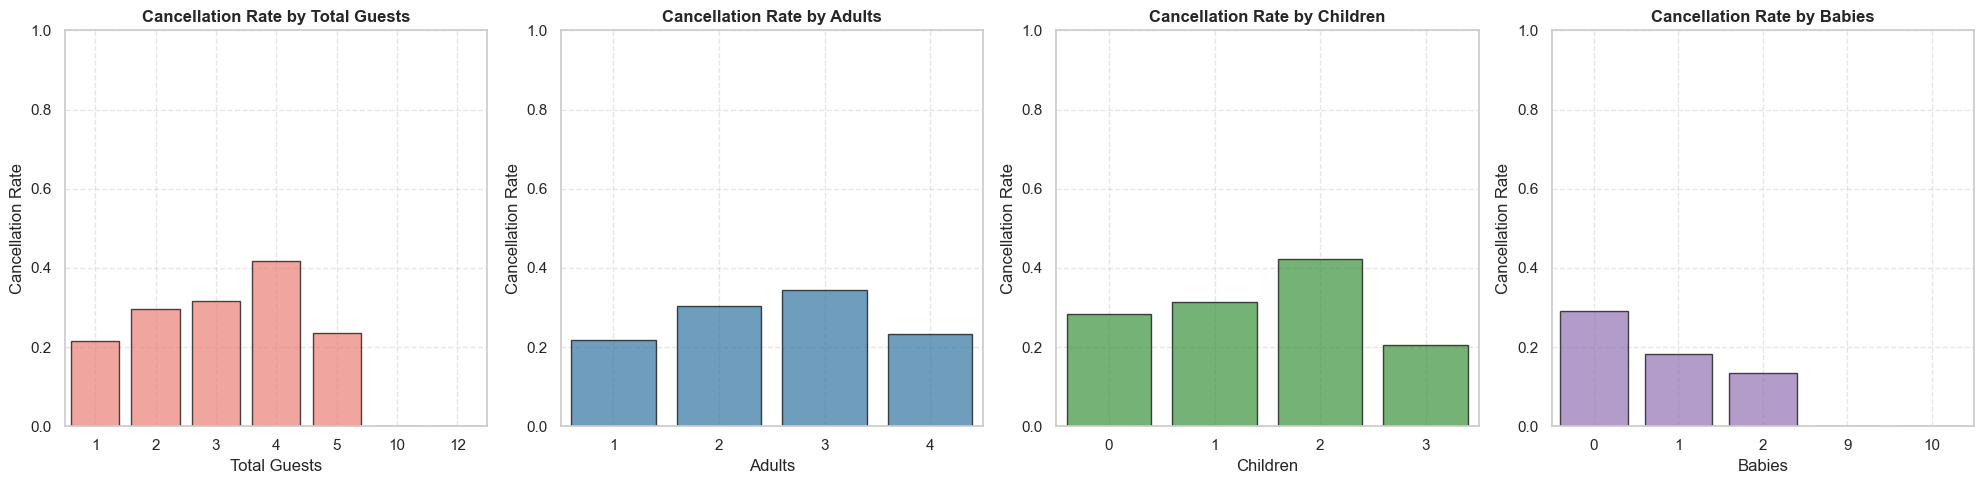

In [7]:
data_plot = df_filtered.copy()
plot_cancellation_guests(data_plot, save_path="../figures/guests_adults_and_children_filter.png")

In [8]:
# =====================================================
# Performance Comparison: Pandas vs DuckDB
# -----------------------------------------------------
# Objective:
#   Find the non-canceled booking with the maximum total_guests
#   and compare the execution time between Pandas and DuckDB.
#
# Method:
#   1️⃣ Pandas: use boolean filtering and idxmax
#   2️⃣ DuckDB: use SQL query to select the same row
#   3️⃣ Measure average runtime over N runs (here 100 runs)
#   4️⃣ Calculate relative speedup between Pandas and DuckDB
#
# Notes:
#   - 'is_canceled == 0' ensures only actual bookings are considered
#   - The MAX(total_guests) is computed within each method
#   - Reduced runs to 100 for practical timing purposes
# =====================================================

import time
import duckdb

pandas_runs = 100
start = time.perf_counter()
for _ in range(pandas_runs):
    idx = df_clean.loc[df_clean['is_canceled'] == 0, 'total_guests'].idxmax()
    row_pandas = df_clean.loc[idx]
end = time.perf_counter()
pandas_avg_time = (end - start) / pandas_runs

duckdb_runs = 100
start = time.perf_counter()
for _ in range(duckdb_runs):
    result_duckdb = duckdb.query("""
        SELECT *
        FROM df_clean
        WHERE is_canceled = 0
        AND total_guests = (
            SELECT MAX(total_guests)
            FROM df_clean
            WHERE is_canceled = 0
        )
    """).to_df()
row_duckdb = result_duckdb.iloc[0]
end = time.perf_counter()
duckdb_avg_time = (end - start) / duckdb_runs

print(f"Summary: \nPandas avg: {pandas_avg_time:.8f}s, DuckDB avg: {duckdb_avg_time:.8f}s")

data_rows = len(df_clean) 
speedup = duckdb_avg_time / pandas_avg_time 

if speedup > 1:
    print(f"Pandas is {speedup:.2f}x faster than DuckDB for {data_rows} rows")
else:
    print(f"DuckDB is {1/speedup:.2f}x faster than Pandas for {data_rows} rows")

Summary: 
Pandas avg: 0.00035393s, DuckDB avg: 0.01028189s
Pandas is 29.05x faster than DuckDB for 78528 rows
